# Platform Comparison: $T_1/t_\mathrm{gate}$ as a Fidelity Predictor

**Q1 — Decay vs. Circuit Depth**: How does qubit decay suppress Grover's success probability as a function of circuit depth, and does the suppression rate scale with $N$?

**Q2 — Cross-Platform Threshold Analysis**: At what circuit depth does each platform's Grover search lose its quantum advantage over classical random guessing, for varying $N$?

**Q3 — $T_1/t_\mathrm{gate}$ as a Fidelity Predictor**: Can the $T_1/t_\mathrm{gate}$ ratio alone rank the four platforms by Grover search fidelity?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

thresholds = pd.read_csv('../data/results/thresholds.csv')
FIGURES_DIR = '../results/figures'

platforms = thresholds['platform'].unique()
N_values = sorted(thresholds['N'].unique())
display(thresholds)

,platform,N,threshold_depth,best_success,T1_us,t_gate_ns,ratio
0,IBM Quantum (Eagle),4,2,0.997004,100,50,2000.000000
1,IBM Quantum (Eagle),8,4,0.938249,100,50,2000.000000
2,IBM Quantum (Eagle),16,6,0.947954,100,50,2000.000000
3,IBM Quantum (Eagle),32,8,0.976952,100,50,2000.000000
4,IBM Quantum (Eagle),64,12,0.958467,100,50,2000.000000
5,IBM Quantum (Eagle),128,17,0.938108,100,50,2000.000000
6,IBM Quantum (Eagle),256,25,0.904789,100,50,2000.000000
7,IBM Quantum (Eagle),1024,50,0.774499,100,50,2000.000000
8,IBM Quantum (Eagle),4096,100,0.545499,100,50,2000.000000
9,IBM Quantum (Eagle),8192,141,0.394718,100,50,2000.000000


## Scatter: $T_1/t_\mathrm{gate}$ vs. Threshold Depth

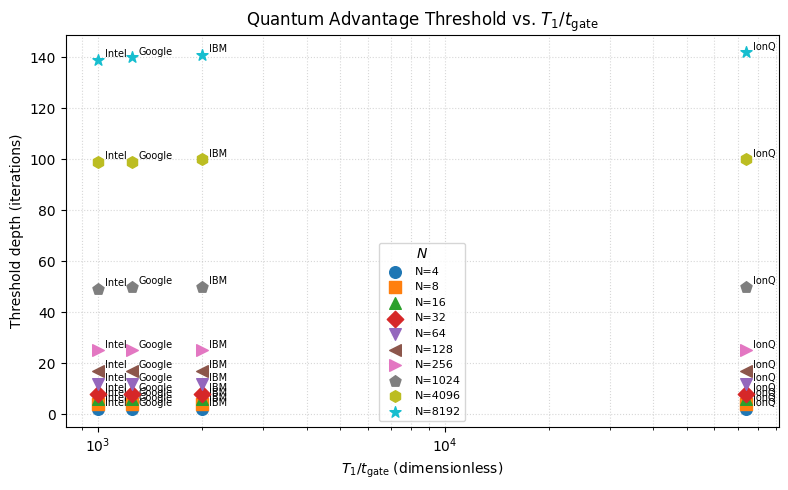

In [2]:
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', '*']

# only plot rows with finite threshold_depth; annotate IonQ off-scale cases separately
finite = thresholds[~np.isinf(thresholds['threshold_depth'])]

fig, ax = plt.subplots(figsize=(8, 5))
for N, marker in zip(N_values, markers[:len(N_values)]):
    sub = finite[finite['N'] == N]
    if sub.empty:
        continue
    ax.scatter(sub['ratio'], sub['threshold_depth'], marker=marker, s=70, label=f'N={N}', zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(
            row['platform'].split()[0],
            (row['ratio'], row['threshold_depth']),
            textcoords='offset points', xytext=(5, 2), fontsize=7,
        )

ionq_inf = thresholds[thresholds['platform'].str.contains('IonQ') & np.isinf(thresholds['threshold_depth'])]
if not ionq_inf.empty:
    ns = ', '.join(str(n) for n in sorted(ionq_inf['N'].tolist()))
    ax.text(0.98, 0.03, f'IonQ: threshold not reached for N = {ns}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=7,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xscale('log')
ax.set_xlabel('$T_1 / t_\\mathrm{gate}$ (dimensionless)')
ax.set_ylabel('Threshold depth (iterations)')
ax.set_title('Quantum Advantage Threshold vs. $T_1/t_\\mathrm{gate}$')
ax.legend(title='$N$', fontsize=8)
ax.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ratio_vs_threshold.png', dpi=150)
plt.show()

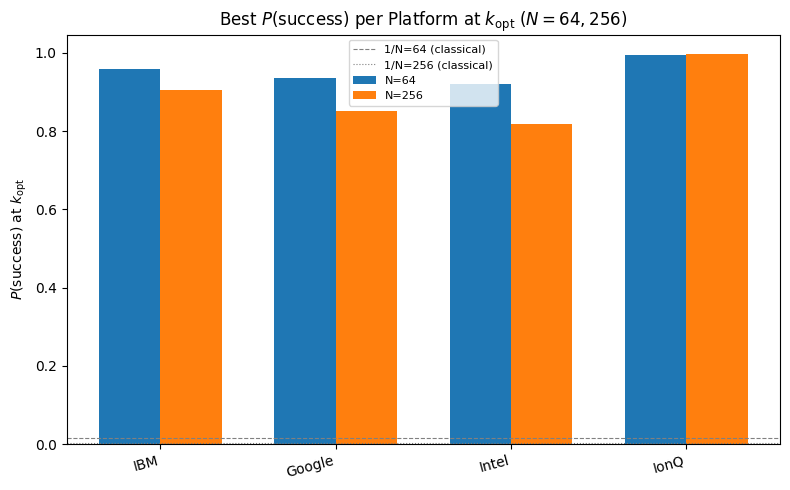

In [3]:
colors_p = {p: c for p, c in zip(platforms, plt.cm.tab10(np.linspace(0, 0.8, len(platforms))))}
N_bar = [64, 256]
x = np.arange(len(platforms))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
for i, N in enumerate(N_bar):
    sub = thresholds[thresholds['N'] == N].set_index('platform')
    vals = [sub.loc[p, 'best_success'] if p in sub.index else 0.0 for p in platforms]
    ax.bar(x + i * width, vals, width, label=f'N={N}')

ax.axhline(1 / 64,  color='gray', linestyle='--', linewidth=0.8, label='1/N=64 (classical)')
ax.axhline(1 / 256, color='gray', linestyle=':',  linewidth=0.8, label='1/N=256 (classical)')
ax.set_xticks(x + width / 2)
ax.set_xticklabels([p.split()[0] for p in platforms], rotation=15, ha='right')
ax.set_ylabel('$P(\mathrm{success})$ at $k_\mathrm{opt}$')
ax.set_title('Best $P(\mathrm{success})$ per Platform at $k_\mathrm{opt}$ ($N=64, 256$)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/best_success_bar.png', dpi=150)
plt.show()